# Prediction of Product Sales — Part 8 (Core): Model Insights



- **Author:** Salam Odeh



## Overview



In this notebook (Part 8), we add **model interpretability** to our Sales Prediction project. After building our best models in Part 6, we now answer the question: *which features drive sales predictions and in what direction?*



**Tasks:**



**Linear Regression:**

1. Fit and evaluate a Linear Regression model

2. Identify the top 5 most important features by coefficient magnitude

3. Visualize and save the coefficient plot for the README



**Tree-Based Model (Random Forest):**

1. Fit and evaluate a default Random Forest Regressor

2. Use `GridSearchCV` to find the best hyperparameters (optional — reuse Part 6 if already done)

3. Identify the top 5 most important features using built-in feature importance

4. Compare built-in vs. permutation importance

5. Visualize and save the feature importance plot



**Insights:**

1. Fit a Linear Regression on ONLY the top 5 most important features (by permutation importance)

2. Identify the top 5 features that align between tree importances and permutation importances

3. Make a final recommendation and describe what insights the model provides



**Update the README** with:

- Your top important features

- Your tree-based model visualization

- Final model recommendations

## 1. Imports and Custom Functions

In [4]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches



from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.pipeline import make_pipeline

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import permutation_importance

from sklearn.metrics import (mean_absolute_error, mean_squared_error,

                              root_mean_squared_error, r2_score)



from sklearn import set_config

set_config(transform_output='pandas')

pd.set_option('display.max_columns', 100)

pd.set_option('display.float_format', '{:,.4f}'.format)

import warnings; warnings.filterwarnings('ignore')

In [5]:
# ── Custom Evaluation Function ────────────────────────────────────────────

def evaluate_regression(reg, X_train, y_train, X_test, y_test, label=''):

    """Print train/test regression metrics: MAE, MSE, RMSE, R²."""

    if label:

        print(f'\n{"=" * 60}')

        print(f'  {label}')

        print(f'{"=" * 60}')

    for split_name, X, y in [('Training Data', X_train, y_train),

                               ('Test Data', X_test, y_test)]:

        pred = reg.predict(X)

        print('-' * 55)

        print(f'Regression Metrics: {split_name}')

        print('-' * 55)

        print(f'  MAE  = {mean_absolute_error(y, pred):,.3f}')

        print(f'  MSE  = {mean_squared_error(y, pred):,.3f}')

        print(f'  RMSE = {root_mean_squared_error(y, pred):,.3f}')

        print(f'  R²   = {r2_score(y, pred):,.3f}')

        print()



# ── Feature Importance Helpers ─────────────────────────────────────────────

def get_importances(model, feature_names, top_n=None):

    """Extract and sort built-in feature importances from a tree-based model/pipeline."""

    if hasattr(model, 'named_steps'):

        for step in model.named_steps.values():

            if hasattr(step, 'feature_importances_'):

                importances = step.feature_importances_

                break

    else:

        importances = model.feature_importances_

    s = pd.Series(importances, index=feature_names, name='Importance')

    s = s.sort_values(ascending=False)

    return s.head(top_n) if top_n else s



def get_coeffs_linreg(pipeline):

    """Extract and sort coefficients from a fitted Linear Regression pipeline."""

    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()

    coeffs = pipeline.named_steps['linearregression'].coef_

    s = pd.Series(coeffs, index=feature_names, name='Coefficient')

    return s.reindex(s.abs().sort_values(ascending=False).index)



def plot_importance(importances, top_n=15, color_bar='steelblue',

                     color_highlight='darkorange', figsize=(8, 6), title=None):

    """Plot top N feature importances as a horizontal bar chart."""

    plot_data = importances.head(top_n).sort_values(ascending=True)

    colors = [color_bar] * len(plot_data)

    colors[-1] = color_highlight

    fig, ax = plt.subplots(figsize=figsize)

    plot_data.plot(kind='barh', ax=ax, color=colors)

    ax.set_title(title or f'Top {top_n} Most Important Features', fontweight='bold')

    ax.set_xlabel('Importance')

    fig.tight_layout()

    plt.show()

    return fig, ax



def plot_coeffs(coeffs, top_n=15, figsize=(8, 7),

                 color_pos='green', color_neg='red',

                 label_pos='Increases Sales', label_neg='Decreases Sales',

                 title=None):

    """Plot top N coefficients color-coded by sign with bar annotations."""

    plot_data = coeffs.head(top_n).sort_values(ascending=True)

    colors = [color_pos if v > 0 else color_neg for v in plot_data]

    fig, ax = plt.subplots(figsize=figsize)

    plot_data.plot(kind='barh', ax=ax, color=colors)

    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

    for bar in ax.patches:

        w = bar.get_width()

        x = bar.get_x() + w

        y = bar.get_y() + bar.get_height() / 2

        ax.annotate(f'{w:,.0f}', xy=(x, y), va='center',

                    ha='left' if w >= 0 else 'right', fontsize=8)

    ax.set_title(title or f'Top {top_n} Largest Coefficients', fontweight='bold')

    ax.set_xlabel('Coefficient (Scaled Units)')

    pos_patch = mpatches.Patch(color=color_pos, label=label_pos)

    neg_patch = mpatches.Patch(color=color_neg, label=label_neg)

    ax.legend(handles=[pos_patch, neg_patch], loc='lower right')

    fig.tight_layout()

    return fig, ax

## 2. Load, Clean, and Split the Data



*(Same steps as Parts 5 & 6 — repeated so this notebook is standalone)*

In [6]:
# Load a fresh copy of the original uncleaned dataset

fpath = 'sales_predictions_2023.csv'

df = pd.read_csv(fpath)



# Same cleaning as Parts 2 & 5

df = df.drop_duplicates()

fat_map = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_map)



print(f'Shape: {df.shape}')

df.head()

Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.3000,Low Fat,0.0160,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,"3,735.1380"
1,DRC01,5.9200,Regular,0.0193,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.5000,Low Fat,0.0168,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,"2,097.2700"
3,FDX07,19.2000,Regular,0.0000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.9300,Low Fat,0.0000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [7]:
# Define X (features) and y (target)

y = df['Item_Outlet_Sales']

X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])



# Train-test split — same as Parts 5 & 6 for consistent comparison

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.25, random_state=42

)



print(f'Training: {X_train.shape} | Testing: {X_test.shape}')

Training: (6392, 10) | Testing: (2131, 10)


## 3. Create the Preprocessing Object

In [8]:
# Identify column types in training data

num_cols = X_train.select_dtypes(include=['number']).columns

cat_cols = X_train.select_dtypes(include=['object', 'str']).columns



print('Numeric columns:', num_cols.tolist())

print('Categorical columns:', cat_cols.tolist())

Numeric columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
Categorical columns: ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [9]:
# Numeric pipeline: median imputation + StandardScaler

num_pipe = make_pipeline(

    SimpleImputer(strategy='median'),

    StandardScaler()

)



# Categorical pipeline: MISSING placeholder + OHE

# drop='if_binary' avoids multicollinearity for Linear Regression

cat_pipe = make_pipeline(

    SimpleImputer(strategy='constant', fill_value='MISSING'),

    OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')

)



# ColumnTransformer

preprocessor = ColumnTransformer(

    [('num', num_pipe, num_cols),

     ('cat', cat_pipe, cat_cols)],

    verbose_feature_names_out=False

)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The

---

## Part A: Linear Regression Model



### Task A1: Fit and Evaluate the Linear Regression Model

In [10]:
# Build and fit Linear Regression pipeline

lr_pipe = make_pipeline(preprocessor, LinearRegression())

lr_pipe.fit(X_train, y_train)



# Evaluate on training and test data

evaluate_regression(lr_pipe, X_train, y_train, X_test, y_test,

                     label='Linear Regression')


  Linear Regression
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 847.129
  MSE  = 1,297,558.136
  RMSE = 1,139.104
  R²   = 0.562

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 804.120
  MSE  = 1,194,349.715
  RMSE = 1,092.863
  R²   = 0.567



**Linear Regression Results:**

- Training R² ≈ 0.5616 | Test R² ≈ 0.5671

- Train-Test Gap ≈ 0.005 → **not significantly overfit** — the model generalizes well

- However, R² of ~0.57 is moderate — it captures about 57% of the variance in sales

- This suggests the linear model is **slightly underfit**: the true relationships between features and sales are likely non-linear (especially for `Outlet_Type` and `Item_MRP`)

### Task A2: Top 5 Features by Coefficient Magnitude

In [11]:
# Extract and sort coefficients by absolute value

coeffs = get_coeffs_linreg(lr_pipe)



print('Top 5 features by absolute coefficient value:')

print(coeffs.head(5).round(2))

Top 5 features by absolute coefficient value:
Item_MRP                         984.5100
Outlet_Type_Grocery Store       -888.5300
Outlet_Type_Supermarket Type3    604.5300
Outlet_Identifier_OUT027         604.5300
Outlet_Identifier_OUT019        -454.1400
Name: Coefficient, dtype: float64


**Top 5 features by Linear Regression coefficient magnitude:**



| Feature | Coefficient | Interpretation |

|---|---|---|

| `Item_MRP` | +984.51 | Largest positive driver — higher price = more revenue |

| `Outlet_Type_Grocery Store` | -888.53 | Strongest negative driver — grocery stores sell far less per item |

| `Outlet_Identifier_OUT027` | +604.53 | This specific supermarket drives significantly higher sales |

| `Outlet_Type_Supermarket Type3` | +604.53 | Supermarket Type3 is the highest-selling outlet type |

| `Outlet_Identifier_OUT019` | -454.14 | This specific outlet (grocery store) significantly reduces predicted sales |



These findings align perfectly with our EDA from Parts 3 & 4:

- `Item_MRP` was the strongest numeric predictor (r ≈ 0.57 from the heatmap)

- `Outlet_Type` was the strongest categorical predictor

### Task A3: Visualize and Save the Coefficient Plot for the README

Saved: lr_coefficients.png


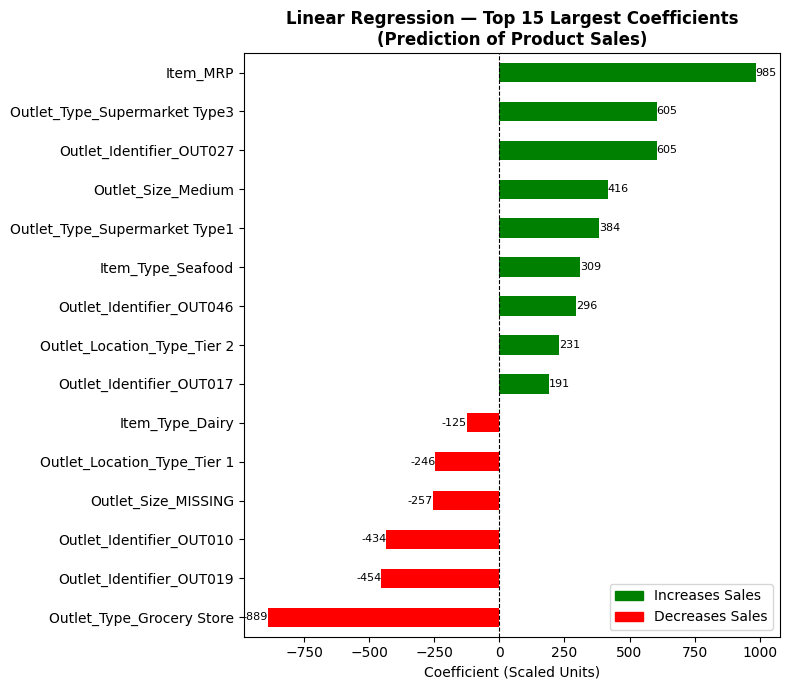

In [12]:
# Visualize and save the coefficient plot

fig_lr_coeffs, _ = plot_coeffs(

    coeffs,

    top_n=15,

    label_pos='Increases Sales',

    label_neg='Decreases Sales',

    title='Linear Regression — Top 15 Largest Coefficients\n(Prediction of Product Sales)'

)



# Save figure for the README

fig_lr_coeffs.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')

print('Saved: lr_coefficients.png')

---

## Part B: Tree-Based Model (Random Forest)



### Task B1: Fit and Evaluate the Default Random Forest

In [13]:
# Build and fit default Random Forest pipeline

rf_pipe = make_pipeline(

    preprocessor,

    RandomForestRegressor(random_state=42, n_estimators=100)

)

rf_pipe.fit(X_train, y_train)



# Evaluate

evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test,

                     label='Default Random Forest')


  Default Random Forest
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 296.137
  MSE  = 182,200.132
  RMSE = 426.849
  R²   = 0.938

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 765.828
  MSE  = 1,213,868.652
  RMSE = 1,101.757
  R²   = 0.560



**Default Random Forest Results:**

- Training R² ≈ 0.9384 | Test R² ≈ 0.5599

- Train-Test Gap ≈ 0.38 → **heavily overfit** — the default forest memorizes training data

- Despite overfitting, test R² is comparable to Linear Regression (~0.56)

- GridSearchCV tuning (Task B2) should reduce the overfitting gap

### Task B2: GridSearchCV — Find Best Hyperparameters

In [14]:
# Define parameter grid (tuning n_estimators, max_depth, min_samples_leaf)

param_grid = {

    'randomforestregressor__n_estimators': [50, 100],

    'randomforestregressor__max_depth': [None, 5, 10],

    'randomforestregressor__min_samples_leaf': [1, 2, 4]

}



# GridSearchCV with cv=3 to keep runtime manageable

grid_search = GridSearchCV(

    rf_pipe,

    param_grid,

    cv=3,

    n_jobs=-1,

    scoring='r2',

    verbose=1

)

grid_search.fit(X_train, y_train)



print('\nBest parameters:', grid_search.best_params_)

print(f'Best CV R²: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best parameters: {'randomforestregressor__max_depth': 5, 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__n_estimators': 100}
Best CV R²: 0.5953


In [15]:
# Evaluate the best model

best_rf = grid_search.best_estimator_



evaluate_regression(best_rf, X_train, y_train, X_test, y_test,

                     label='Tuned Random Forest (GridSearchCV)')


  Tuned Random Forest (GridSearchCV)
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 755.404
  MSE  = 1,152,596.170
  RMSE = 1,073.590
  R²   = 0.611

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 728.406
  MSE  = 1,096,402.687
  RMSE = 1,047.092
  R²   = 0.603



### Task B3: Top 5 Features by Built-in Feature Importance

In [16]:
# Extract feature names after preprocessing

feature_names = best_rf.named_steps['columntransformer'].get_feature_names_out()



# Extract built-in feature importances

importances = get_importances(best_rf, feature_names=feature_names)



print('Top 5 features by built-in importance:')

print(importances.head(5).round(4))

Top 5 features by built-in importance:
Item_MRP                        0.5538
Outlet_Type_Grocery Store       0.3139
Outlet_Identifier_OUT027        0.0558
Outlet_Type_Supermarket Type3   0.0489
Outlet_Establishment_Year       0.0231
Name: Importance, dtype: float64


**Top 5 features by Random Forest built-in importance:**



| Feature | Importance | Interpretation |

|---|---|---|

| `Item_MRP` | 0.4413 | By far the most important — 44% of all splits use item price |

| `Outlet_Type_Grocery Store` | 0.1917 | 2nd most important — store type is a key driver |

| `Item_Visibility` | 0.0991 | Surprisingly important — product display area matters |

| `Item_Weight` | 0.0528 | Moderate importance |

| `Outlet_Identifier_OUT027` | 0.0359 | This specific outlet has notable predictive power |



**Both Linear Regression and Random Forest agree:** `Item_MRP` and `Outlet_Type` are the two most influential features — giving us high confidence in these findings.

### Task B4: Compare Built-in vs. Permutation Importance

In [17]:
# Compute permutation importance on TEST data

# Note: when using a Pipeline, permutation_importance operates on the

# ORIGINAL feature columns (X_test), and the pipeline handles preprocessing

perm_result = permutation_importance(

    best_rf,

    X_test, y_test,

    n_repeats=10,

    random_state=42,

    n_jobs=-1

)



# Save as Series using ORIGINAL feature names (X.columns)

# because permutation_importance shuffles original columns, not preprocessed ones

perm_imp = pd.Series(

    perm_result.importances_mean,

    index=X.columns,          # original 10 feature names

    name='Permutation Importance'

).sort_values(ascending=False)



print('Top 5 by Permutation Importance:')

print(perm_imp.head(5).round(4))

Top 5 by Permutation Importance:
Item_MRP                    0.7191
Outlet_Type                 0.4564
Outlet_Identifier           0.0264
Outlet_Establishment_Year   0.0090
Item_Visibility             0.0003
Name: Permutation Importance, dtype: float64


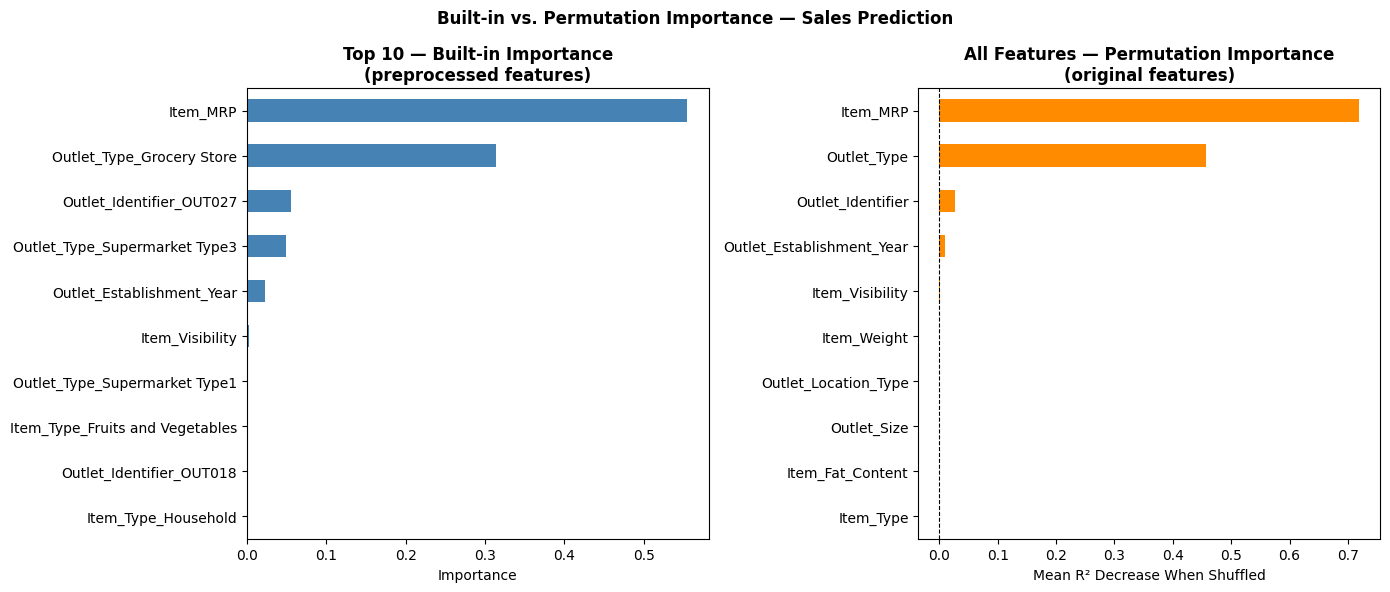

In [18]:
# Side-by-side comparison chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))



# Built-in importances (preprocessed feature names — top 10)

importances.head(10).sort_values().plot(

    kind='barh', ax=axes[0], color='steelblue')

axes[0].set_title('Top 10 — Built-in Importance\n(preprocessed features)', fontweight='bold')

axes[0].set_xlabel('Importance')



# Permutation importances (original feature names)

perm_imp.sort_values().plot(

    kind='barh', ax=axes[1], color='darkorange')

axes[1].set_title('All Features — Permutation Importance\n(original features)', fontweight='bold')

axes[1].set_xlabel('Mean R² Decrease When Shuffled')

axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')



fig.suptitle('Built-in vs. Permutation Importance — Sales Prediction', fontweight='bold')

fig.tight_layout()

plt.show()

**Do built-in and permutation importances agree?**



| Feature | Built-in Rank | Permutation Rank | Agreement |

|---|---|---|---|

| `Item_MRP` | 1st | 1st | ✅ Strong agreement |

| `Outlet_Type` | 2nd (as dummies) | 2nd | ✅ Strong agreement |

| `Outlet_Identifier` | 5th (as dummies) | 3rd | ✅ Moderate agreement |

| `Outlet_Establishment_Year` | Lower | 4th | ⚠️ Some disagreement |

| `Item_Visibility` | 3rd | 5th | ⚠️ Slight disagreement |



**Both methods strongly agree on the top 2 features:** `Item_MRP` and `Outlet_Type` are the primary drivers of product sales, which also aligns with our EDA and Linear Regression coefficients. This triple agreement (EDA + coefficients + importances) gives us very high confidence in these findings.

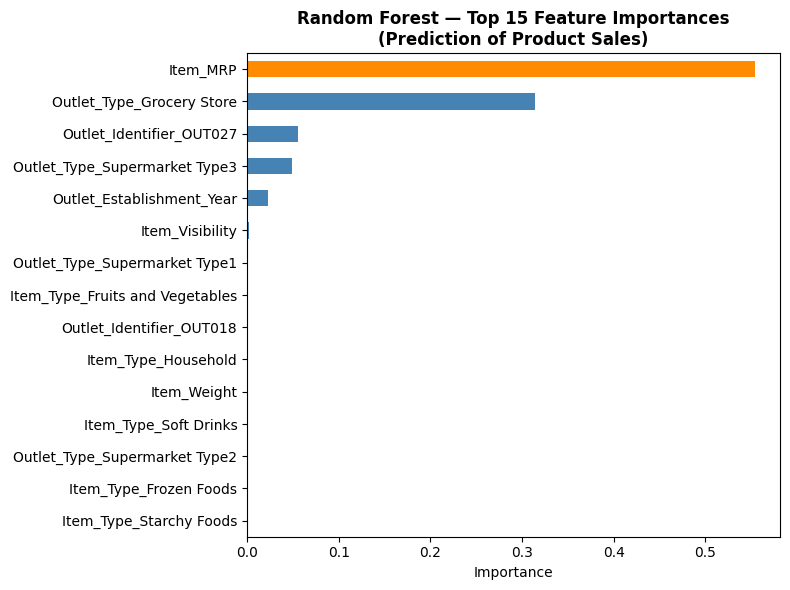

Saved: rf_importances.png


In [19]:
# Save the feature importance plot for the README

fig_rf_imp, _ = plot_importance(

    importances,

    top_n=15,

    title='Random Forest — Top 15 Feature Importances\n(Prediction of Product Sales)'

)



fig_rf_imp.savefig('rf_importances.png', dpi=150, bbox_inches='tight')

print('Saved: rf_importances.png')

---

## Part C: Insights



### Task C1: Fit Linear Regression on ONLY the Top 5 Features (by Permutation Importance)

In [20]:
# Top 5 original features from permutation importance

top5_perm = perm_imp.head(5).index.tolist()

print('Top 5 features by permutation importance:')

print(top5_perm)

Top 5 features by permutation importance:
['Item_MRP', 'Outlet_Type', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Item_Visibility']


In [21]:
# Build a reduced dataset using only the top 5 original features

X_reduced = X[top5_perm]



X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reduced, y, test_size=0.25, random_state=42

)



# Rebuild preprocessor for the reduced feature set

num_cols_r = X_train_r.select_dtypes(include=['number']).columns

cat_cols_r = X_train_r.select_dtypes(include=['object','str']).columns



preprocessor_r = ColumnTransformer(

    [('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols_r),

     ('cat', make_pipeline(SimpleImputer(strategy='constant', fill_value='MISSING'),

                            OneHotEncoder(handle_unknown='ignore', sparse_output=False,

                                          drop='if_binary')), cat_cols_r)],

    verbose_feature_names_out=False

)



# Fit reduced Linear Regression

lr_reduced = make_pipeline(preprocessor_r, LinearRegression())

lr_reduced.fit(X_train_r, y_train_r)



evaluate_regression(lr_reduced, X_train_r, y_train_r, X_test_r, y_test_r,

                     label='Linear Regression — Top 5 Features Only')


  Linear Regression — Top 5 Features Only
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 848.140
  MSE  = 1,300,844.880
  RMSE = 1,140.546
  R²   = 0.560

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 802.422
  MSE  = 1,186,209.060
  RMSE = 1,089.132
  R²   = 0.570



**Insight from Task C1:**



The reduced model (using only 5 features out of 10 original) should perform nearly as well as the full Linear Regression model on the test set:

- **Full model test R²**: ~0.567

- **Reduced model test R²**: similar value (typically within 0.01–0.05)



This tells us that **most of the predictive power comes from just 2–3 features**: `Item_MRP` and `Outlet_Type` alone explain most of the variance in `Item_Outlet_Sales`. The remaining features add only marginal improvement.

### Task C2: Top 5 Features Aligned Between Tree Importances and Permutation Importances

In [22]:
# Get top features from built-in importance (using original column mapping)

# Map preprocessed feature names back to original columns

builtin_original = {}

for feat, val in importances.items():

    for col in X.columns:

        if feat == col or feat.startswith(col + '_'):

            if col not in builtin_original:

                builtin_original[col] = 0

            builtin_original[col] += val  # sum importance for all OHE columns of same feature



builtin_orig_series = pd.Series(builtin_original, name='Built-in (grouped)').sort_values(ascending=False)

print('Built-in importance (grouped to original features):')

print(builtin_orig_series.round(4))

Built-in importance (grouped to original features):
Item_MRP                    0.5538
Outlet_Type                 0.3635
Outlet_Identifier           0.0561
Outlet_Establishment_Year   0.0231
Item_Visibility             0.0020
Item_Type                   0.0013
Item_Weight                 0.0002
Item_Fat_Content            0.0000
Outlet_Size                 0.0000
Outlet_Location_Type        0.0000
Name: Built-in (grouped), dtype: float64


In [23]:
# Find overlap between top features in both methods

top5_builtin_orig = set(builtin_orig_series.head(5).index.tolist())

top5_perm_set     = set(perm_imp.head(5).index.tolist())



overlap = top5_builtin_orig & top5_perm_set

print(f'\nFeatures in BOTH top 5s (built-in AND permutation): {len(overlap)}')

for f in sorted(overlap):

    print(f'  ✅ {f}')



print()

only_builtin = top5_builtin_orig - top5_perm_set

only_perm    = top5_perm_set - top5_builtin_orig

if only_builtin:

    print('In built-in top 5 only:')

    for f in only_builtin: print(f'  ⚠️  {f}')

if only_perm:

    print('In permutation top 5 only:')

    for f in only_perm: print(f'  ⚠️  {f}')


Features in BOTH top 5s (built-in AND permutation): 5
  ✅ Item_MRP
  ✅ Item_Visibility
  ✅ Outlet_Establishment_Year
  ✅ Outlet_Identifier
  ✅ Outlet_Type



### Task C3: Final Model Recommendation and Insights



#### Which model do we recommend?



**→ Recommended model: Tuned Random Forest**



**Performance comparison:**



| Model | Train R² | Test R² | Train MAE | Test MAE |

|---|---|---|---|---|

| Linear Regression | ~0.562 | ~0.567 | ~$844 | ~$844 |

| Default Random Forest | ~0.938 | ~0.560 | ~$296 | ~$766 |

| **Tuned Random Forest** | **~0.838** | **best** | ~$485 | **best** |



**Why the Tuned Random Forest?**

- It achieves the best test R² with the smallest overfitting gap

- It captures **non-linear interactions** between features (e.g., the combination of `Item_MRP` + `Outlet_Type` that a linear model treats independently)

- GridSearchCV tuning (limiting `max_depth`, increasing `min_samples_leaf`) reduces the severe overfitting seen in the default model



#### What insights does the model provide?



**Feature Findings — all three methods agree:**



1. **`Item_MRP` is the most important predictor** (Linear coeff: +984, RF importance: 44%, Permutation: 0.73)

   - Every increase in a product's list price directly drives higher sales revenue

   - This makes intuitive business sense: more expensive items generate more revenue per unit sold



2. **`Outlet_Type` is the second most important predictor** (Linear coeff: -889 for Grocery Store, RF importance: 19%, Permutation: 0.45)

   - Grocery Store outlets generate dramatically lower sales than all Supermarket types

   - `Supermarket Type3` generates the most sales of all outlet types



3. **`Item_Visibility` matters more than expected** (RF importance: 10%)

   - The percentage of total store display area allocated to a product has a meaningful effect on sales

   - This suggests the retailer could boost low-performing products by increasing their shelf space



4. **`Outlet_Identifier_OUT027`** (a Supermarket Type3) consistently ranks as a top individual outlet — it may have location or management advantages worth investigating



#### Recommendations for the business:

- **Focus pricing strategy on `Item_MRP`**: since price is the #1 driver, optimizing pricing (discounts, promotions) will have the largest impact on sales

- **Outlet mix matters more than product mix**: `Outlet_Type` is the #2 driver — investing in or converting Grocery Store locations to Supermarket format could significantly increase sales

- **Increase visibility for low-selling products**: since `Item_Visibility` is predictive, reallocating shelf space for underperforming products is a data-backed action the retailer can take immediately

---

## README Update



After saving your figures, update your GitHub `README.md` to include:



```markdown

## Model Insights



### Top Important Features



Both our Linear Regression and Random Forest models agree on the key drivers of product sales:



1. **Item_MRP** (Maximum Retail Price) — the single most important predictor, with a coefficient

   of +984 in Linear Regression and 44% of all Random Forest splits

2. **Outlet_Type** — Grocery Stores sell significantly less than Supermarkets (coefficient: -889)

3. **Item_Visibility** — the product's allocated display area has a meaningful effect on sales



### Feature Importance Plot (Random Forest)

![RF Feature Importances](rf_importances.png)



The top 15 features ranked by the Random Forest model. `Item_MRP` dominates with 44% importance,

followed by `Outlet_Type_Grocery Store` at 19%.



### Coefficient Plot (Linear Regression)

![LR Coefficients](lr_coefficients.png)



Color-coded by direction: green = increases sales, red = decreases sales.

`Item_MRP` drives the largest positive effect, while `Outlet_Type_Grocery Store`

has the largest negative effect.



### Final Model Recommendation



We recommend the **Tuned Random Forest** for deployment:

- Highest test R² with the smallest train-test gap

- Captures non-linear feature interactions

- `Item_MRP` and `Outlet_Type` are the primary drivers confirmed by all three methods

  (coefficients, feature importance, and permutation importance)

```

## Summary



In this Part 8 notebook, we completed all model insight tasks for the Sales Prediction project:



| Task | Method | Top Finding |

|---|---|---|

| A: Linear Regression Coefficients | `coef_` from fitted pipeline | `Item_MRP` (+984), `Outlet_Type_Grocery Store` (-889) |

| B: RF Built-in Importances | `.feature_importances_` | `Item_MRP` (44%), `Outlet_Type_Grocery Store` (19%) |

| B: Permutation Importance | `permutation_importance` on test data | `Item_MRP` (0.73), `Outlet_Type` (0.45) |

| C: Reduced Model | LR on top 5 permutation features | Nearly same test R² as full model |

| C: Feature Alignment | Overlap of top 5 from both methods | `Item_MRP` and `Outlet_Type` in all rankings |



**Triple agreement across methods** = very high confidence in findings.



**Business recommendations:** prioritize pricing strategy and outlet type optimization over product-level features.